# Ant Colony Optimization para enrutamiento extremo a extremo

Este notebook implementa **Ant Colony Optimization (ACO)** para encontrar una ruta de bajo costo entre un nodo origen y un nodo destino en una red.

La idea central no es simular físicamente el movimiento de hormigas, sino representar el mecanismo de búsqueda de ACO sobre un **grafo**. Cada enlace de la red mantiene una cantidad de feromona $\tau_{ij}$, que funciona como una memoria colectiva de la calidad histórica de ese enlace dentro de las rutas construidas por la colonia.

El notebook está diseñado para trabajar de dos maneras:

- ejecutar **una iteración a la vez** mediante `aco.step()`, observando cómo cambian las feromonas;
- ejecutar muchas iteraciones consecutivas mediante `aco.run(n)` cuando ya se quiera estudiar el comportamiento global del algoritmo.

Después de cada iteración se puede visualizar el valor exacto de feromona de todos los enlaces.

## 1. Modelo de red

La red se representa mediante un grafo no dirigido

$$
G=(V,E),
$$

donde $V$ es el conjunto de routers o nodos y $E$ es el conjunto de enlaces disponibles.

Cada enlace $(i,j)$ tiene un costo positivo

$$
c_{ij}>0.
$$

En este ejemplo el costo puede interpretarse como latencia, distancia o cualquier otra métrica aditiva de enrutamiento.

Buscamos una ruta desde un nodo origen \(s\) hasta un nodo destino \(d\) que minimice

$$
L(R)=\sum_{(i,j)\in R} c_{ij}.
$$

ACO no necesita resolver directamente este problema mediante enumeración exhaustiva. La colonia construye rutas probabilísticamente y refuerza los enlaces pertenecientes a soluciones de buena calidad.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from dataclasses import dataclass

np.random.seed(7)

## 2. Definición del grafo

Usaremos una red pequeña para que sea posible observar con claridad todos los valores de feromona.

El atributo `cost` representa el costo de atravesar cada enlace. Las posiciones de los nodos se fijan manualmente únicamente para conseguir una visualización estable entre iteraciones.

In [2]:
G = nx.Graph()

edges = [
    ("A", "B", 4),
    ("A", "C", 3),
    ("A", "D", 7),
    ("B", "C", 2),
    ("B", "E", 5),
    ("B", "F", 8),
    ("C", "D", 4),
    ("C", "E", 6),
    ("C", "F", 5),
    ("D", "F", 3),
    ("D", "G", 8),
    ("E", "F", 2),
    ("E", "H", 6),
    ("F", "G", 3),
    ("F", "H", 4),
    ("G", "H", 2),
    ("G", "I", 4),
    ("H", "I", 3),
    ("H", "J", 5),
    ("I", "J", 2),
]

for u, v, cost in edges:
    G.add_edge(u, v, cost=float(cost))

pos = {
    "A": (0, 1.5),
    "B": (1.5, 2.5),
    "C": (1.5, 1.2),
    "D": (1.5, 0.0),
    "E": (3.2, 2.7),
    "F": (3.2, 1.2),
    "G": (4.8, 0.2),
    "H": (4.8, 2.0),
    "I": (6.3, 1.0),
    "J": (7.8, 1.5),
}

source = "A"
target = "J"

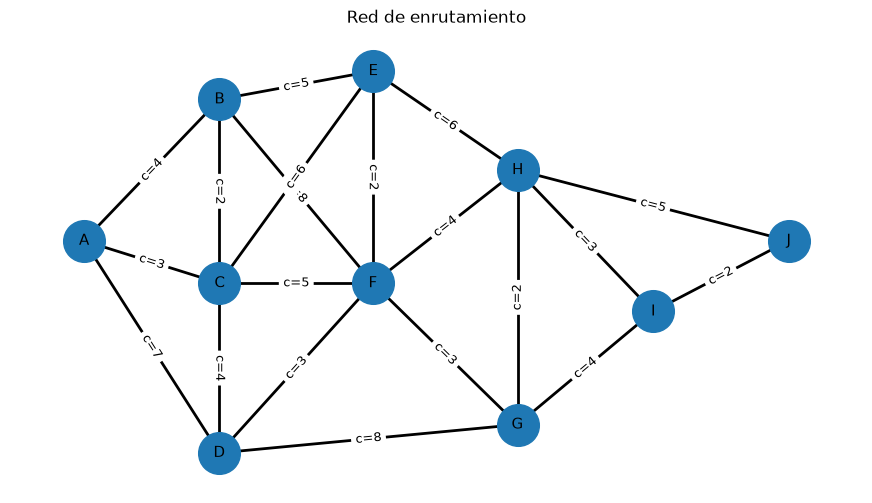

In [3]:
plt.figure(figsize=(11, 6))

nx.draw_networkx_nodes(G, pos, node_size=900)
nx.draw_networkx_labels(G, pos, font_size=11)
nx.draw_networkx_edges(G, pos, width=2)

edge_labels = {
    (u, v): f"c={data['cost']:.0f}"
    for u, v, data in G.edges(data=True)
}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

plt.title("Red de enrutamiento")
plt.axis("off")
plt.show()

## 3. Información heurística

ACO combina dos fuentes de información al escoger el siguiente enlace.

La primera es la **feromona**

$$
\tau_{ij},
$$

que representa la experiencia acumulada por la colonia.

La segunda es una medida heurística local

$$
\eta_{ij}=\frac{1}{c_{ij}},
$$

de modo que un enlace de menor costo tiene inicialmente mayor atractivo.

Para una hormiga \(k\) situada en el nodo \(i\), la probabilidad de escoger el vecino \(j\) es

$$
P_{ij}^{(k)}
=
\frac{
\tau_{ij}^{\alpha}
\eta_{ij}^{\beta}
}{
\sum_{l\in N_i^{(k)}}
\tau_{il}^{\alpha}
\eta_{il}^{\beta}
}.
$$

El conjunto $N_i^{(k)}$ contiene los vecinos disponibles que la hormiga todavía puede visitar.

Los parámetros tienen una interpretación directa:

- $\alpha$: importancia de la experiencia colectiva almacenada en las feromonas;
- $\beta$: importancia de la heurística local asociada al costo del enlace.

Cuando las feromonas son inicialmente iguales, las primeras decisiones dependen principalmente de la heurística y del componente aleatorio.

## 4. Actualización de feromonas

Una iteración completa de ACO tiene dos etapas.

Primero, todas las hormigas construyen una ruta desde el origen hasta el destino.

Después ocurre la actualización de feromonas.

### Evaporación

Todas las feromonas disminuyen según

$$
\tau_{ij}\leftarrow (1-\rho)\tau_{ij},
$$

donde $0<\rho<1$ es la tasa de evaporación.

La evaporación evita que las decisiones tomadas al comienzo permanezcan indefinidamente en la memoria del algoritmo.

### Depósito

Si la hormiga $k$ construyó una ruta $R_k$ de costo $L_k$, deposita

$$
\Delta\tau_{ij}^{(k)}
=
\frac{Q}{L_k}
$$

en cada enlace perteneciente a esa ruta.

Por tanto, las rutas de menor costo producen un depósito mayor.

La actualización completa es

$$
\tau_{ij}
\leftarrow
(1-\rho)\tau_{ij}
+
\sum_k \Delta\tau_{ij}^{(k)}.
$$

In [4]:
@dataclass
class AntSolution:
    path: list
    cost: float
    reached_target: bool


class ACO:
    def __init__(
        self,
        graph,
        source,
        target,
        n_ants=20,
        alpha=1.0,
        beta=2.0,
        rho=0.20,
        Q=10.0,
        tau0=1.0,
        seed=42,
    ):
        self.G = graph.copy()
        self.source = source
        self.target = target
        self.n_ants = n_ants
        self.alpha = alpha
        self.beta = beta
        self.rho = rho
        self.Q = Q
        self.tau0 = tau0
        self.rng = np.random.default_rng(seed)

        self.iteration = 0
        self.best_path = None
        self.best_cost = np.inf
        self.last_solutions = []
        self.history_best = []
        self.history_tau = []

        for u, v in self.G.edges(): #Se almacenan los valores iniciales de feromona y eligibilidad para cada arista
            self.G[u][v]["tau"] = float(tau0)
            self.G[u][v]["eta"] = 1.0 / self.G[u][v]["cost"]

        self._save_tau_snapshot() #Almacena los valores iniciales de las feromonas de cada enlace

    def _edge_key(self, u, v): #Devuelve una tupla ordenada que representa una arista en el grafo, independientemente del orden de los nodos. Esto asegura que la arista (u, v) y (v, u) se consideren iguales.
        return tuple(sorted((u, v)))

    def _path_cost(self, path): #Calcula el costo total de una ruta sumando los costos de cada arista en la ruta
        return sum(
            self.G[path[i]][path[i + 1]]["cost"]
            for i in range(len(path) - 1)
        )

    def _construct_solution(self): #Función que construye una solución (ruta) para una hormiga desde el nodo fuente hasta el nodo objetivo, siguiendo las reglas del algoritmo de optimización por colonia de hormigas.
        current = self.source
        path = [current]
        visited = {current}

        while current != self.target:
            candidates = [
                j for j in self.G.neighbors(current)
                if j not in visited
            ]

            if not candidates:
                return AntSolution(path, np.inf, False)

            desirability = np.array([
                self.G[current][j]["tau"] ** self.alpha
                * self.G[current][j]["eta"] ** self.beta
                for j in candidates
            ], dtype=float)

            if desirability.sum() <= 0:
                probabilities = np.ones(len(candidates)) / len(candidates)
            else:
                probabilities = desirability / desirability.sum()

            next_node = self.rng.choice(candidates, p=probabilities)

            path.append(next_node)
            visited.add(next_node)
            current = next_node

        return AntSolution(path, self._path_cost(path), True) #Lo que se retorna finalmente es un objeto de la clase AntSolution que contiene la ruta construida, 
                                                              #su costo total y un indicador de si se alcanzó el nodo objetivo.

    def _evaporate(self):
        for u, v in self.G.edges():
            self.G[u][v]["tau"] *= (1.0 - self.rho)

    def _deposit(self, solutions):
        for sol in solutions:
            if not sol.reached_target:
                continue

            delta = self.Q / sol.cost

            for u, v in zip(sol.path[:-1], sol.path[1:]):
                self.G[u][v]["tau"] += delta

    def _save_tau_snapshot(self): #Almacena los valores de feromona en cada iteración para su posterior análisis
        snapshot = {
            self._edge_key(u, v): self.G[u][v]["tau"]
            for u, v in self.G.edges()
        }
        self.history_tau.append(snapshot)

    def step(self, verbose=True):
        solutions = [
            self._construct_solution()
            for _ in range(self.n_ants)
        ]

        self._evaporate()
        self._deposit(solutions)

        valid = [s for s in solutions if s.reached_target]

        if valid:
            iteration_best = min(valid, key=lambda s: s.cost)

            if iteration_best.cost < self.best_cost:
                self.best_cost = iteration_best.cost
                self.best_path = iteration_best.path.copy()
        else:
            iteration_best = None

        self.iteration += 1
        self.last_solutions = solutions
        self.history_best.append(self.best_cost)
        self._save_tau_snapshot()

        if verbose:
            print(f"Iteración: {self.iteration}")

            if iteration_best is not None:
                print(
                    "Mejor ruta de la iteración:",
                    " -> ".join(iteration_best.path)
                )
                print(
                    f"Costo de la mejor ruta de la iteración: "
                    f"{iteration_best.cost:.2f}"
                )
            else:
                print("Ninguna hormiga alcanzó el destino.")

            print(
                "Mejor ruta global:",
                " -> ".join(self.best_path)
                if self.best_path is not None
                else "No disponible"
            )
            print(f"Mejor costo global: {self.best_cost:.2f}")

        return solutions

    def run(self, n, verbose=False):
        for _ in range(n):
            self.step(verbose=verbose)

        print(f"Se ejecutaron {n} iteraciones.")
        print(f"Iteración actual: {self.iteration}")
        print("Mejor ruta:", " -> ".join(self.best_path))
        print(f"Mejor costo: {self.best_cost:.2f}")

    def pheromones(self):
        return {
            self._edge_key(u, v): self.G[u][v]["tau"]
            for u, v in self.G.edges()
        }

## 5. Inicialización del algoritmo

Todos los enlaces comienzan con la misma cantidad de feromona

$$
\tau_{ij}(0)=\tau_0.
$$

Esto significa que al comienzo no existe todavía conocimiento colectivo acerca de qué enlaces forman buenas rutas.

En el ejemplo usamos:

$$
\alpha=1,\qquad
\beta=2,\qquad
\rho=0.20.
$$

Por tanto, inicialmente la heurística local tiene bastante influencia, pero a medida que avanzan las iteraciones la feromona comienza a modificar las probabilidades de selección.

In [22]:
aco = ACO(
    G,
    source=source,
    target=target,
    n_ants=2,
    alpha=1.0,
    beta=2.0,
    rho=0.20,
    Q=10.0,
    tau0=1.0,
    seed=7,
)

## 6. Visualización de las feromonas

La siguiente función representa simultáneamente dos aspectos de cada enlace:

- el número escrito sobre el enlace corresponde al valor exacto de \(\tau_{ij}\);
- el grosor del enlace aumenta con la cantidad de feromona acumulada.

De esta manera puede observarse directamente cómo la colonia va concentrando su búsqueda sobre determinados caminos.

In [6]:
def draw_pheromones(aco, pos, show_cost=False):
    plt.figure(figsize=(12, 7))

    tau = {
        (u, v): aco.G[u][v]["tau"]
        for u, v in aco.G.edges()
    }

    max_tau = max(tau.values()) if tau else 1.0

    widths = [
        1.0 + 7.0 * aco.G[u][v]["tau"] / max_tau
        for u, v in aco.G.edges()
    ]

    nx.draw_networkx_nodes(
        aco.G,
        pos,
        node_size=900,
    )

    nx.draw_networkx_labels(
        aco.G,
        pos,
        font_size=11,
    )

    nx.draw_networkx_edges(
        aco.G,
        pos,
        width=widths,
        alpha=0.75,
    )

    if show_cost:
        labels = {
            (u, v):
            f"τ={aco.G[u][v]['tau']:.2f}\nc={aco.G[u][v]['cost']:.0f}"
            for u, v in aco.G.edges()
        }
    else:
        labels = {
            (u, v): f"{aco.G[u][v]['tau']:.2f}"
            for u, v in aco.G.edges()
        }

    nx.draw_networkx_edge_labels(
        aco.G,
        pos,
        edge_labels=labels,
        font_size=8,
        rotate=False,
    )

    if aco.best_path is not None:
        best_edges = list(zip(
            aco.best_path[:-1],
            aco.best_path[1:]
        ))

        nx.draw_networkx_edges(
            aco.G,
            pos,
            edgelist=best_edges,
            width=4,
        )

    plt.title(
        f"Feromonas después de la iteración {aco.iteration}"
    )
    plt.axis("off")
    plt.show()

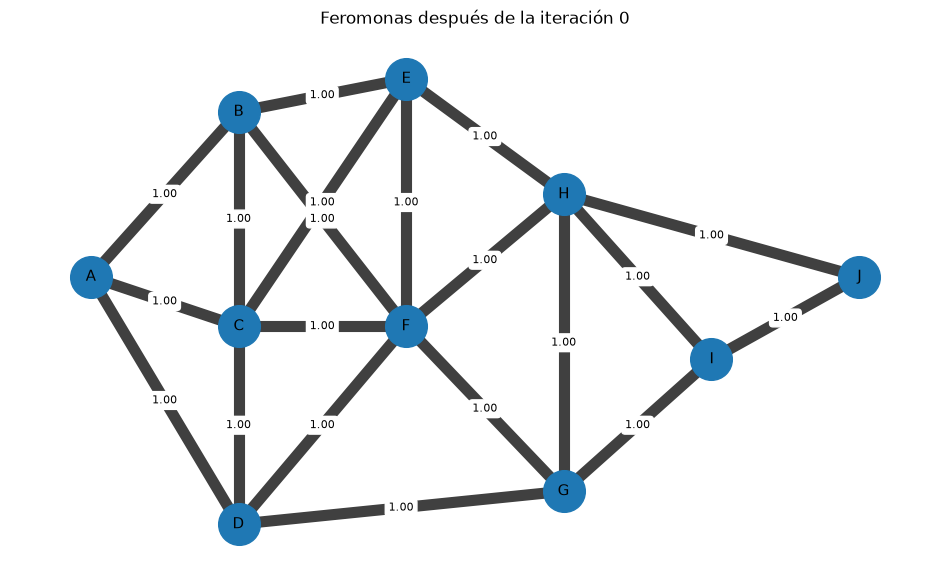

In [7]:
draw_pheromones(aco, pos)

## 7. Ejecutar una sola iteración

La operación fundamental para estudiar el algoritmo es

`aco.step()`

Una llamada a este método representa **una iteración completa de ACO**:

1. todas las hormigas construyen una ruta;
2. las feromonas existentes se evaporan;
3. las rutas encontradas depositan nueva feromona;
4. se conserva la mejor solución encontrada hasta el momento.

Después de ejecutar la celda siguiente puede volverse a ejecutar tantas veces como se desee. Cada ejecución avanza exactamente una iteración.

Iteración: 1
Mejor ruta de la iteración: A -> C -> F -> G -> H -> I -> J
Costo de la mejor ruta de la iteración: 18.00
Mejor ruta global: A -> C -> F -> G -> H -> I -> J
Mejor costo global: 18.00


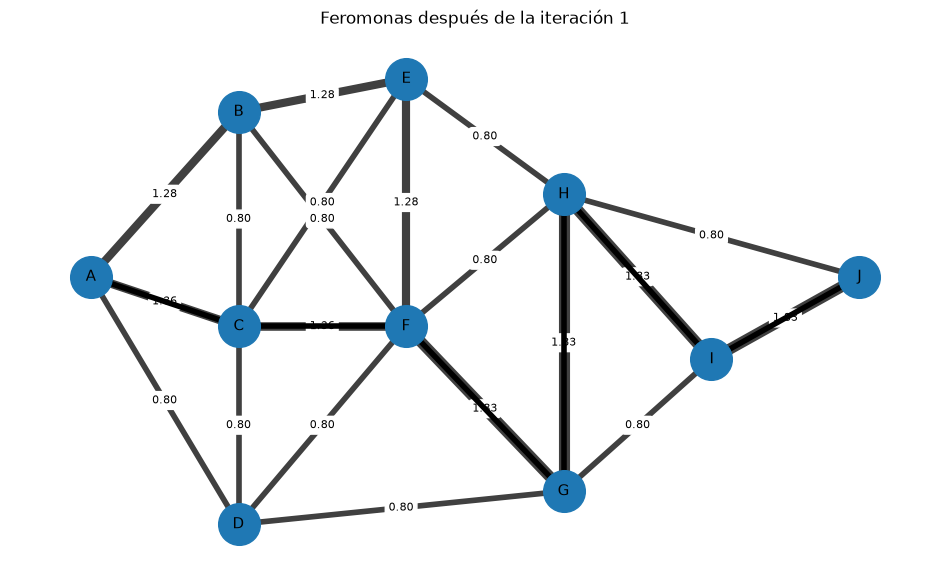

In [23]:
aco.step()
draw_pheromones(aco, pos)

Puede ser útil ejecutar manualmente la celda anterior varias veces y observar qué ocurre.

Al comienzo las diferencias entre enlaces suelen ser pequeñas. Después de varias iteraciones algunos enlaces comienzan a presentar valores de feromona sistemáticamente mayores.

Ese fenómeno constituye la memoria colectiva de ACO: las soluciones individuales desaparecen después de cada iteración, pero la información que dejaron permanece parcialmente en los enlaces.

## 8. Consultar numéricamente las feromonas

Además de la representación gráfica, podemos consultar directamente el valor de \(\tau_{ij}\) de todos los enlaces.

In [9]:
for edge, tau in sorted(aco.pheromones().items()):
    print(f"{edge}: tau = {tau:.4f}")

('A', 'B'): tau = 20.2130
('A', 'C'): tau = 39.5702
('A', 'D'): tau = 6.8658
('B', 'C'): tau = 41.1670
('B', 'E'): tau = 27.0610
('B', 'F'): tau = 4.9141
('C', 'D'): tau = 17.8569
('C', 'E'): tau = 5.4787
('C', 'F'): tau = 11.9760
('D', 'F'): tau = 31.2005
('D', 'G'): tau = 15.0815
('E', 'F'): tau = 41.7426
('E', 'H'): tau = 15.5598
('F', 'G'): tau = 23.8728
('F', 'H'): tau = 14.2640
('G', 'H'): tau = 47.2580
('G', 'I'): tau = 24.1087
('H', 'I'): tau = 34.9991
('H', 'J'): tau = 10.8755
('I', 'J'): tau = 54.9736


## 9. Ejecutar muchas iteraciones

Después de estudiar manualmente la evolución del algoritmo puede ser innecesario continuar ejecutando una iteración a la vez.

El método

`aco.run(n)`

ejecuta automáticamente \(n\) iteraciones consecutivas.

Por ejemplo, la siguiente instrucción ejecuta 200 iteraciones adicionales.

Se ejecutaron 200 iteraciones.
Iteración actual: 201
Mejor ruta: A -> C -> F -> G -> H -> I -> J
Mejor costo: 18.00


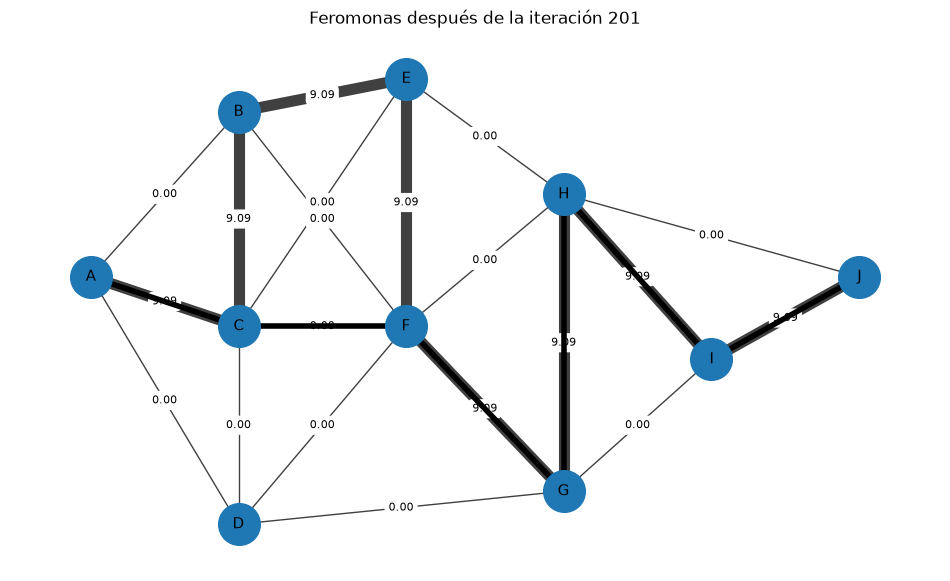

In [21]:
# Descomentar cuando se quiera avanzar automáticamente:
aco.run(200)
draw_pheromones(aco, pos)

## 10. Evolución temporal de las feromonas

El objeto `ACO` almacena una copia de todas las feromonas después de cada iteración.

Esto permite estudiar

$$
\tau_{ij}(t)
$$

como una variable que evoluciona en el tiempo.

La siguiente función representa la historia de todos los enlaces. Cuando la colonia converge, algunos enlaces tienden a acumular considerablemente más feromona que los demás.

In [11]:
def plot_pheromone_history(aco):
    edges = list(aco.history_tau[0].keys())
    iterations = np.arange(len(aco.history_tau))

    plt.figure(figsize=(12, 7))

    for edge in edges:
        values = [
            snapshot[edge]
            for snapshot in aco.history_tau
        ]
        plt.plot(
            iterations,
            values,
            label=f"{edge[0]}-{edge[1]}"
        )

    plt.xlabel("Iteración")
    plt.ylabel("Feromona")
    plt.title("Evolución de las feromonas")
    plt.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )
    plt.grid(alpha=0.25)
    plt.show()

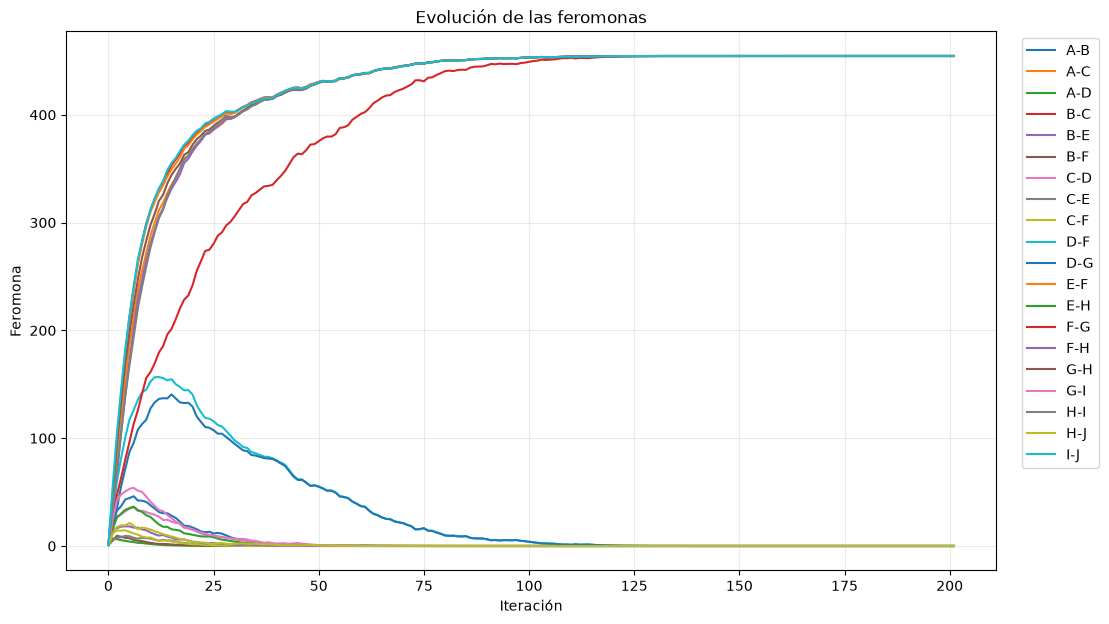

In [12]:
plot_pheromone_history(aco)

## 11. Evolución de la mejor solución

Otra variable relevante es el mejor costo conocido después de cada iteración.

Si

$$
L^*(t)
$$

representa el mejor costo descubierto hasta la iteración \(t\), esta cantidad solo puede mantenerse o disminuir.

La gráfica permite observar en qué momento la colonia descubre soluciones mejores y cuándo deja de producir mejoras.

In [13]:
def plot_best_cost(aco):
    plt.figure(figsize=(9, 5))
    plt.plot(
        range(1, len(aco.history_best) + 1),
        aco.history_best,
        marker="o",
        markersize=3,
    )
    plt.xlabel("Iteración")
    plt.ylabel("Mejor costo encontrado")
    plt.title("Convergencia de ACO")
    plt.grid(alpha=0.3)
    plt.show()

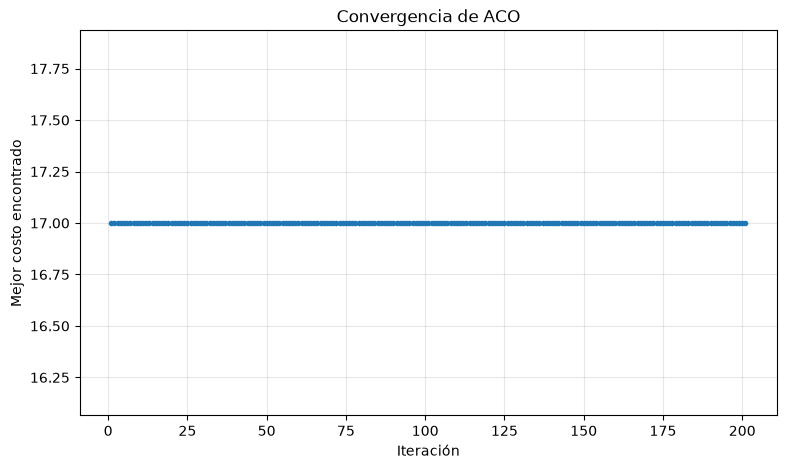

In [14]:
plot_best_cost(aco)

## 12. Comparación con el camino mínimo

En este problema particular existe un algoritmo exacto y muy eficiente: Dijkstra.

No utilizamos Dijkstra para construir la solución ACO. Lo usamos únicamente como referencia para determinar qué tan buena fue la ruta encontrada por la colonia.

Esta comparación ayuda a distinguir dos ideas:

- **Dijkstra** resuelve específicamente el problema de camino mínimo;
- **ACO** es una metaheurística general de construcción de soluciones que puede adaptarse posteriormente a problemas de enrutamiento con restricciones y funciones objetivo mucho más complejas.

In [15]:
optimal_path = nx.shortest_path(
    G,
    source=source,
    target=target,
    weight="cost"
)

optimal_cost = nx.shortest_path_length(
    G,
    source=source,
    target=target,
    weight="cost"
)

print("Ruta óptima:", " -> ".join(optimal_path))
print(f"Costo óptimo: {optimal_cost:.2f}")

if aco.best_path is not None:
    gap = 100 * (aco.best_cost - optimal_cost) / optimal_cost
    print()
    print("Mejor ruta ACO:", " -> ".join(aco.best_path))
    print(f"Costo ACO: {aco.best_cost:.2f}")
    print(f"Gap: {gap:.2f}%")

Ruta óptima: A -> C -> F -> H -> J
Costo óptimo: 17.00

Mejor ruta ACO: A -> C -> F -> H -> I -> J
Costo ACO: 17.00
Gap: 0.00%


## 13. Interpretación

La variable fundamental de ACO no es únicamente la mejor ruta encontrada.

El estado del algoritmo está representado por el conjunto

$$
\{\tau_{ij}\}_{(i,j)\in E}.
$$

Cada iteración modifica estos valores mediante dos mecanismos opuestos:

$$
\text{olvido: evaporación}
$$

y

$$
\text{aprendizaje: depósito de feromona}.
$$

Por esta razón, observar las feromonas después de cada iteración permite estudiar directamente cómo evoluciona la búsqueda.

Una ruta puede aparecer como la mejor solución de una iteración y desaparecer posteriormente. Sin embargo, si determinados enlaces participan repetidamente en soluciones de buena calidad, su feromona aumenta y la probabilidad de que futuras hormigas vuelvan a utilizarlos también aumenta.

La solución global emerge así de la interacción entre **exploración aleatoria, información heurística y memoria colectiva**.